# Relaxed Poisson Distribution

Hadi's version: https://openreview.net/forum?id=ektPEcqGLb

In [1]:
# HIDE CODE


project_name = '_PoissonGradEstim'


import os, sys
from IPython.display import display

# tmp & extras dir (replace with your own paths)
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

## Poisson args

You need to provide two things:

1. `log_rate`: log of firing rates (real numbers)

2. `temp`: non-negative temperature (`temp=0.0` corresponds to true Poisson)

3. `n_exp`: number of exponential draws (integer)

**Note:** See Algorithm 1 here: https://openreview.net/pdf?id=ektPEcqGLb
- `n_exp` is the same as the one shown in there
- `log_rate` is just **$\log\mathbf{\lambda}$**

In [2]:
from main.distributions import Poisson

### Make Poisson dists

In [3]:
# firing rates
lamb = torch.tensor([0.5, 1, 2, 8])

# number of exponential draws
n_exp = 200

# various temperatures
temperatures = [
    0.0, 0.01, 0.05, 0.1, 0.2, 0.3,
    0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0,
]


batch_size = 10_000

kws = dict(
    log_rate=torch.log(lamb.expand(
        (batch_size, -1))).cuda(),
    clamp=None,
    n_exp=n_exp,
)

# dictionary of distributions (various temperatures)
dists = {
    t: Poisson(temp=t, **kws)
    for t in temperatures
}

### Draw samples

In [4]:
n_samples = int(1e5)

samples = collections.defaultdict(list)

for _ in tqdm(range(n_samples // batch_size)):
    for t, dist in dists.items():
        samples[t].append(dist.rsample())

samples = {
    t: tonp(torch.cat(s).T)
    for t, s in samples.items()
}

100%|██████████████████████████████████████████| 10/10 [00:00<00:00, 148.96it/s]


### Put data as dataframe

In [5]:
%%time


df = []

for t, samp in samples.items():
    for i, s in enumerate(samp):
        df.append({
            'Temperature': [t] * len(s),
            'lamb': [tonp(lamb)[i]] * len(s),
            'index': np.arange(len(s)),
            'sample': s,
        })

df = pd.DataFrame(merge_dicts(df))

len(df) / n_samples / len(lamb) / len(temperatures)

CPU times: user 7.24 s, sys: 446 ms, total: 7.69 s
Wall time: 7.66 s


1.0

### Plot

In [6]:
muted = sns.color_palette('muted')
muted

[(0.2823529411764706, 0.47058823529411764, 0.8156862745098039),
 (0.9333333333333333, 0.5215686274509804, 0.2901960784313726),
 (0.41568627450980394, 0.8, 0.39215686274509803),
 (0.8392156862745098, 0.37254901960784315, 0.37254901960784315),
 (0.5843137254901961, 0.4235294117647059, 0.7058823529411765),
 (0.5490196078431373, 0.3803921568627451, 0.23529411764705882),
 (0.8627450980392157, 0.49411764705882355, 0.7529411764705882),
 (0.4745098039215686, 0.4745098039215686, 0.4745098039215686),
 (0.8352941176470589, 0.7333333333333333, 0.403921568627451),
 (0.5098039215686274, 0.7764705882352941, 0.8862745098039215)]

In [7]:
# color palette
pal_temp = {
    0.0: 'k', 
    0.01: muted[2],
    0.1: muted[3],
    1.0: muted[0],
}

# binning
upper = 5
n_bins = 50
width = upper / n_bins
bins = np.linspace(0, upper + width, n_bins + 3)
bins -= 3 * width / 2

In [8]:
selected_lamb = [0.5, 1.0]

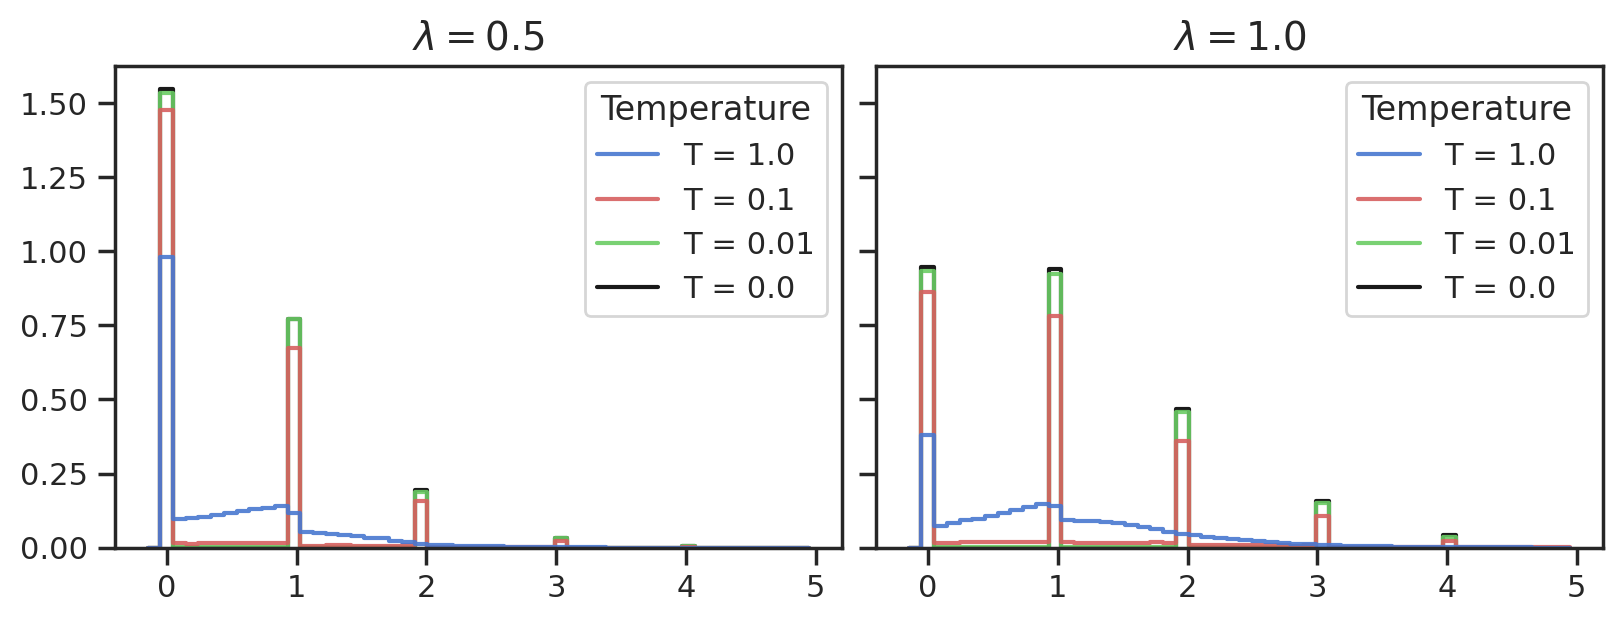

In [9]:
fig, axes = create_figure(1, 2, (8, 3.0), sharey=True, dpi=200)


for i, lam in enumerate(selected_lamb):
    ax = axes[i]
    _d2p = df.loc[
        (df['lamb'] == lam) &
        (df['Temperature'].isin(pal_temp))
    ]

    sns.histplot(
        _d2p,
        x='sample',
        hue='Temperature',
        bins=bins,
        palette=pal_temp,
        alpha=0.9,
        stat='density',
        element='step',
        fill=False,
        hue_order=[1.0, 0.1, 0.01, 0.0],
        ax=ax,
    )
    ax.set(xlabel='', ylabel='')
    ax.set_title(r"$\lambda = $" + f"{lam}", fontsize=14)

    legend = ax.get_legend()
    for text in legend.get_texts():
        text.set_text(f"T = {text.get_text()}")

# fig.savefig(pjoin(fig_dir, 'samples_hist.pdf'), **kws_fig)
plt.show()

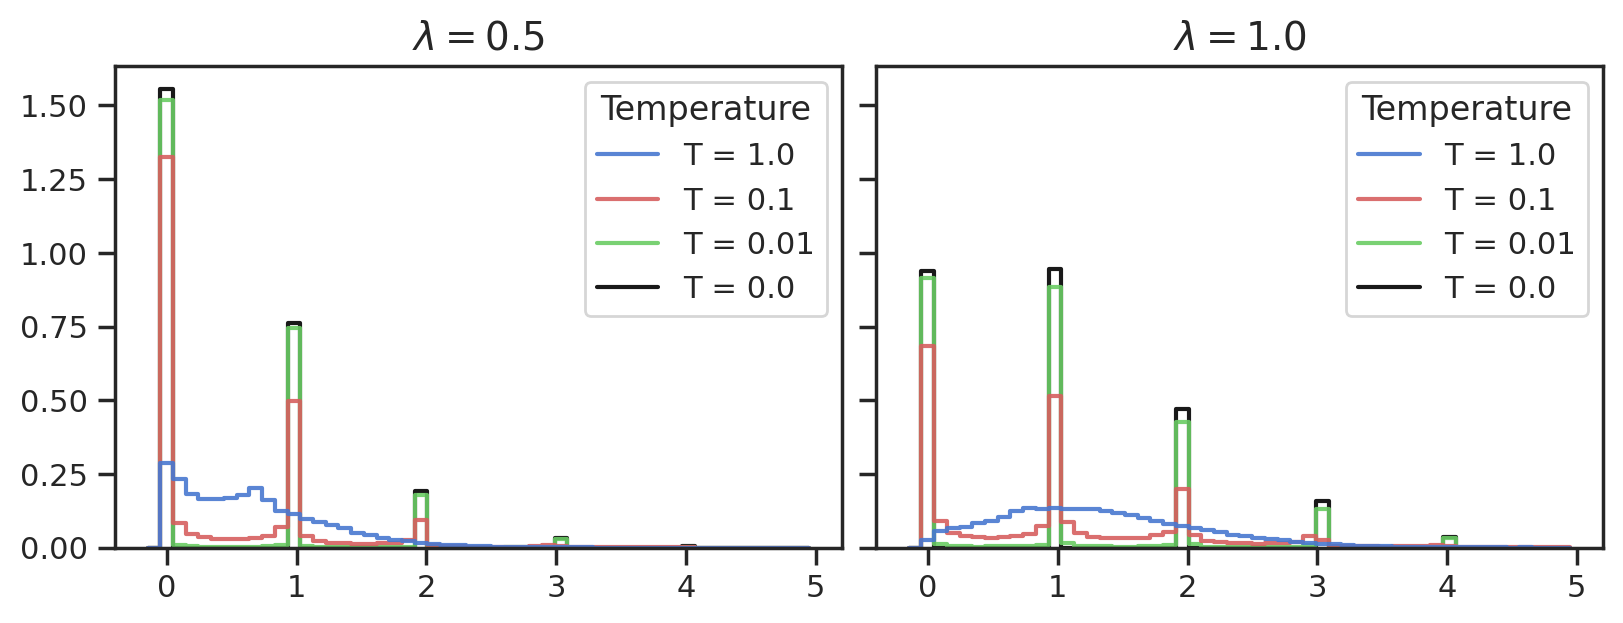

## The effect of temperature on step function

In Algorithm 1, we have this step:

$\mathrm{indicator} \gets \text{sigmoid}\left(\frac{1 - \mathrm{times}}{\mathrm{temperature}}\right)$

This is just approximating the Heaviside step function. Let's see how it looks like for various nonzero temperatures.

### Define functions

In [10]:
def step_function(x):
    return np.where(x >= 0, 1, 0)

def sigmoid(x, t=1.0):
    return 1 / (1 + np.exp(-x / t))

### Make plots

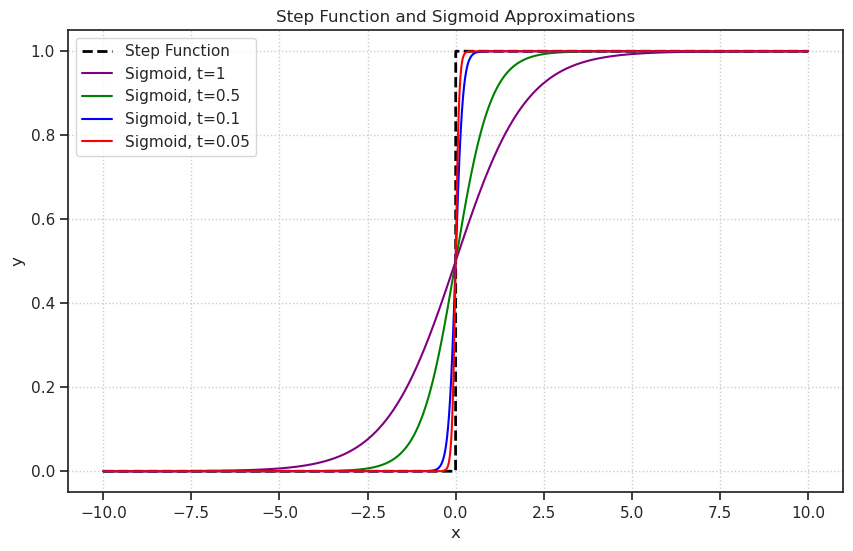

In [11]:
x = np.linspace(-10, 10, 10000)

plt.figure(figsize=(10, 6))
plt.plot(x, step_function(x), label='Step Function', color='black', lw=2, ls='--')

temperatures = [1, 0.5, 0.1, 0.05]
colors = ['purple', 'green', 'blue', 'red']
for t, c in zip(temperatures, colors):
    plt.plot(x, sigmoid(x, t), label=f'Sigmoid, t={t}', color=c)

plt.title('Step Function and Sigmoid Approximations')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

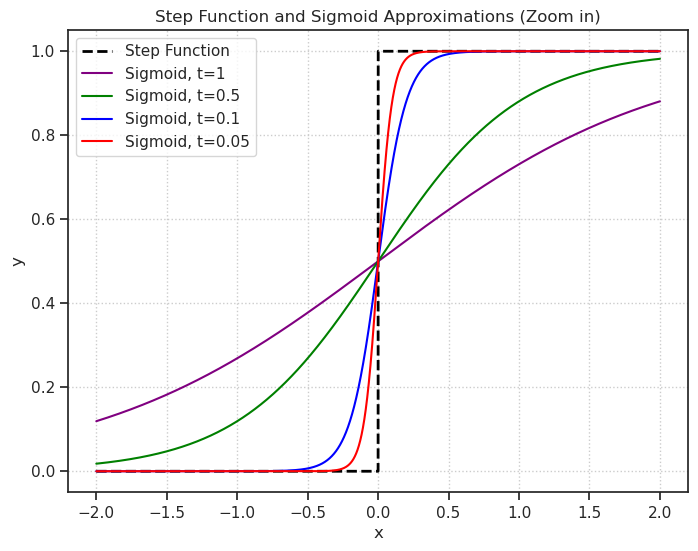

In [12]:
x = np.linspace(-2, 2, 10000)

plt.figure(figsize=(8, 6))
plt.plot(x, step_function(x), label='Step Function', color='black', lw=2, ls='--')

temperatures = [1, 0.5, 0.1, 0.05]
colors = ['purple', 'green', 'blue', 'red']
for t, c in zip(temperatures, colors):
    plt.plot(x, sigmoid(x, t), label=f'Sigmoid, t={t}', color=c)

plt.title('Step Function and Sigmoid Approximations (Zoom in)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

### What if we used something else?

Use `HardSigmoid` instead:

```Python
y = torch.clamp(0.5 * x / temp + 0.5, min=0.0, max=1.0)
```

This should be less sensitive to temperature.

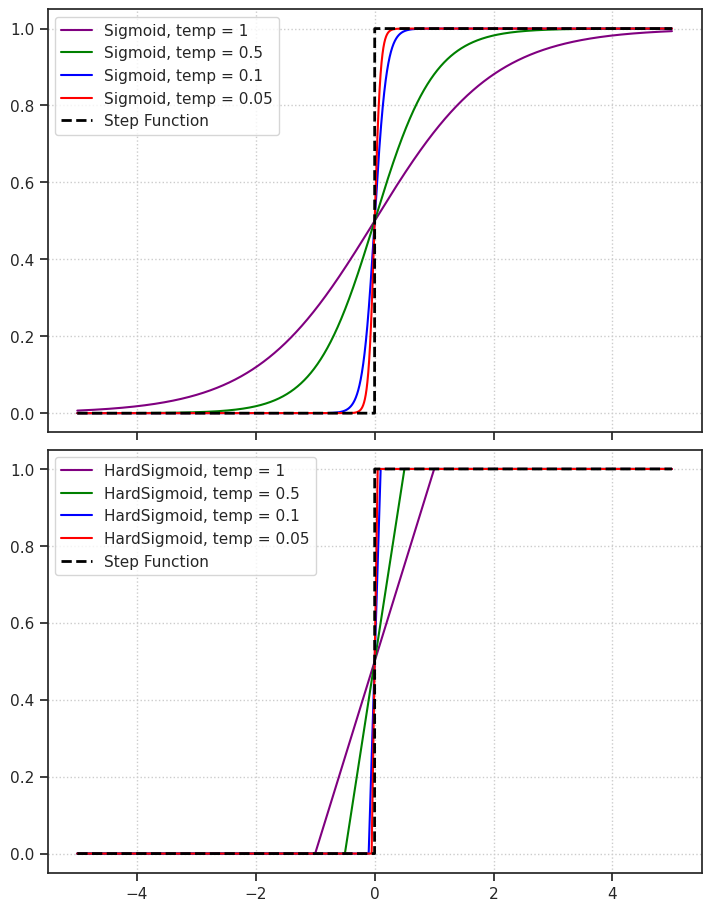

In [13]:
x = torch.linspace(-5, 5, 10000)

fig, axes = create_figure(2, 1, figsize=(7, 9), sharex='all')

temperatures = [1, 0.5, 0.1, 0.05]
colors = ['purple', 'green', 'blue', 'red']
for temp, c in zip(temperatures, colors):
    y = tonp(torch.sigmoid(x / temp))
    axes[0].plot(x, y, label=f'Sigmoid, temp = {temp}', color=c)
    
    y = tonp(torch.clamp(0.5 * x / temp + 0.5, min=0.0, max=1.0))
    axes[1].plot(x, y, label=f'HardSigmoid, temp = {temp}', color=c)

y = tonp(torch.where(x >= 0, 1, 0))
for ax in axes.flat:
    ax.plot(x, y, label='Step Function', color='black', lw=2, ls='--')
    ax.legend()
    ax.grid()
    
plt.show()